# Gene module selection for the early timepoint: scRNA-seq mouse data

<br>

In this notebook, we obtain the module of genes $G_{early}$ for the early timepoints (D3-D4) as discussed in Appendix A (Data Analysis) in [1]:

* __Section A1.1:__ Outward clustering and gene module selection in scRNA-seq data,
* __Section A1.2:__ Choice and use of marker genes.

The functions for this notebook can be found in `GeneModules_RNAseq.py`. The dataset originates from [2].

[1] M. Fontaine, J.M. Delas, M. Saez, R.J. Maizels, E. Finnie, J. Briscoe, D.A. Rand, (2025). *Dynamic Landscape Analysis of Cell Fate Decisions: Predictive Models of Neural Development From Single-Cell Data*. bioR$\chi$iv doi: https://doi.org/10.1101/2025.05.28.656648

[2] R. J. Maizels, D. M. Snell, and J. Briscoe. *Reconstructing developmental trajectories using latent dynamical systems and time-resolved transcriptomics*. Cell Systems, 15(5), (2024), doi: https://doi.org/10.1016/j.cels.2024.04.004

---
<sub>Author: Marine Fontaine (Warwick)</sub>

### **1.** Load packages and data

In [2]:
# --- Standard analysis libraries ---
import sys
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Import the gene-module helper functions (defined in GeneModules_RNAseq.py)
from GeneModules_RNAseq import calculate_mean_and_percentile_distance, collect_samples,get_genelist_by_day

In [6]:
# --- Load the dataset and prepare a log-normalised copy ---

#wd = ''  # current folder
wd = '/Users/marinefontaine/Documents/Python/DynamicalLandscapeAnalysis_new/RNAseqDataAnalysis/'  # original path
datafile = wd + 'NeuralEarly_celltype.h5ad' 
adata_counts = sc.read_h5ad(datafile)   # raw counts (kept untouched for clustering/saving)
adata_counts

AnnData object with n_obs × n_vars = 22358 × 24967
    obs: 'X_TC_alpha', 'total_TC_alpha', 'unspliced_TC_alpha', 'spliced_TC_alpha', 'p_e', 'p_c_TC', 'sample', 'timepoint', 'rep', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'label_rate', 'doublet_score', 'marker_based_classification', 'cell_annotation', 'domain', 'leiden', 'celltype'
    layers: 'new', 'old', 'total'

In [8]:
# remove mitochondrial and ribosomal genes

non_mito_genes_list = [name for name in adata_counts.var_names if not name.startswith('mt-')]
adata_no_mito_genes = adata_counts[:, non_mito_genes_list]

non_rp_genes_list = [name for name in adata_no_mito_genes.var_names
                     if not (name.startswith('Rpl') or name.startswith('Rps'))]
adata_no_rp_genes = adata_no_mito_genes[:, non_rp_genes_list]

# Log-normalise the filtered data 
adata = adata_no_rp_genes.copy()
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 22358 × 24730
    obs: 'X_TC_alpha', 'total_TC_alpha', 'unspliced_TC_alpha', 'spliced_TC_alpha', 'p_e', 'p_c_TC', 'sample', 'timepoint', 'rep', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'label_rate', 'doublet_score', 'marker_based_classification', 'cell_annotation', 'domain', 'leiden', 'celltype'
    uns: 'log1p'
    layers: 'new', 'old', 'total'

### **2.** Module of genes $G_{early}$
#### **2.1.** Define 1-marker samples

In [11]:
# Build one "1-marker sample" of cells per marker gene
grouped_data1=collect_samples(
    data=adata, 
    genes=['Foxa2', 'Foxc2', 'Olig2', 'T'], # choose your markers
    confidence=95, # choose confidence interval for the expression of the lognormalised counts
    key='group1' #give name to your group
)

{'mainplot_ax': <Axes: >,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

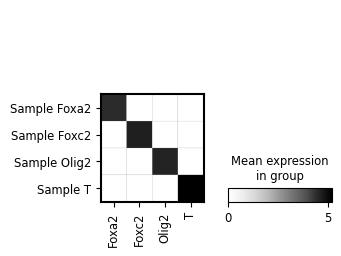

In [13]:
sc.pl.matrixplot(grouped_data1, ['Foxa2', 'Foxc2', 'Olig2', 'T'], groupby='group1', show=False, cmap='Greys')

#### **2.2.** Find genes

In [16]:
# Select the early gene module G_early: extreme-tail DE genes between


genelist1=get_genelist_by_day(
    data=grouped_data1,
    group='group1',
    alpha=99.98,
    days=adata.obs['timepoint'].unique().tolist()
)

In [17]:
# Inspect the selected gene module
genelist1


array(['9030622O22Rik', 'Adgrv1', 'Arhgap28', 'Arid1b', 'B430203G13Rik',
       'Braf', 'Calr', 'Ccnc', 'Ccnd2', 'Cct6a', 'Cdh1', 'Cdx1', 'Cdx2',
       'Cep57', 'Cfap100', 'Chd6', 'Chmp7', 'Clic4', 'Colec12', 'Cracd',
       'Csrnp3', 'Cul1', 'Dlg1', 'Dlgap3', 'Dst', 'Epcam', 'Fbn2', 'Fn1',
       'Foxa2', 'Foxc1', 'Foxc2', 'Foxo3', 'Frem2', 'Fst', 'Fzd3',
       'Galnt16', 'Gap43', 'Gatc', 'Gja1', 'Gli2', 'Glud1', 'Gm43421',
       'Gm6051', 'Gm6166', 'Gpc3', 'Gria4', 'Grip1', 'Grsf1', 'Gucy1a2',
       'Heatr1', 'Heatr6', 'Hoxaas3', 'Hoxb5os', 'Hoxb9', 'Hspa5',
       'Ints2', 'Irx3', 'Itga6', 'Jmjd1c', 'Kalrn', 'Khdrbs1', 'Kif26b',
       'Lef1', 'Limch1', 'Lrp8', 'Lyar', 'Man2a1', 'Map1b', 'Mcc',
       'Meis1', 'Meox1', 'Msi2', 'Ncoa2', 'Nectin2', 'Nkx1-2', 'Nkx6-1',
       'Nrg2', 'Ntn1', 'Olig2', 'Pak1', 'Pax3', 'Pcdh19', 'Pcsk5',
       'Pde4d', 'Pdia5', 'Pdzrn3', 'Peg10', 'Pid1', 'Pla2g7', 'Prune2',
       'Ptch1', 'Ptk7', 'Ptn', 'Ptpn14', 'Ralbp1', 'Rap1gds1', 'Rbms1',
     

In [22]:
# Number of genes in the module
len(genelist1)

139

#### **2.3** Restrict dataset to the gene modules $G_{early}$

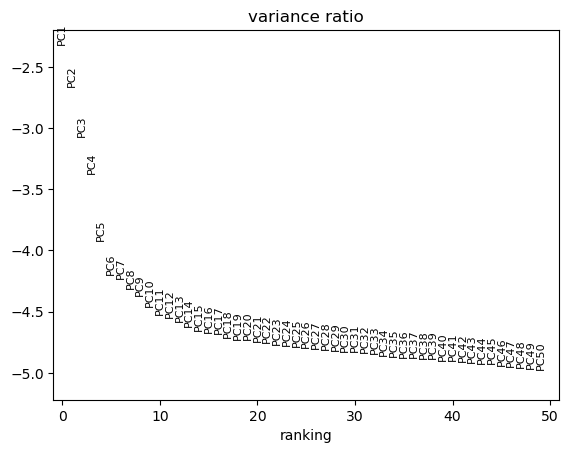

In [25]:
# Restrict dataset to the selected gene module, then run PCA.
# The variance-ratio (elbow) plot guides how many PCs to keep below.
neural_states=adata[:,adata.var_names.isin(genelist1)].copy()

# Perform pca for leiden clustering
sc.tl.pca(neural_states, svd_solver='arpack')
sc.pl.pca_variance_ratio(neural_states, log=True, n_pcs=50)

#### **2.4** Leiden clustering

In [ ]:
# Leiden clustering on this subset of genes (choose 7 first PCs cf. elbow plot)

sc.pp.neighbors(neural_states, n_neighbors=10, n_pcs=7, random_state=0)
sc.tl.leiden(neural_states, resolution=1.5, random_state=0)  # fixed seed for reproducible cluster IDs

# add leiden to raw data (with all genes)
adata_counts.obs['leiden']=neural_states.obs['leiden']


sc.set_figure_params(scanpy=True, fontsize=15)
from matplotlib.pyplot import rc_context
with rc_context({'figure.figsize': (8, 8), 'savefig.dpi': 300}): 
    sc.pl.pca(
        neural_states, 
        color='leiden', 
        add_outline=True,
        legend_fontsize=20, 
        s=35, 
        legend_fontoutline=10, 
        frameon=True,
        title='',
        legend_loc='on data'
    )

#### **2.5** Annotate

In [28]:
# Map each Leiden cluster ID to a cell-type label
annotations = {
    '0':'NMPTrans',
    '1':'p2', 
    '2':'Meso',
    '3':'PreNeural', 
    '4':'PreNeural',
    '5':'NMP',
    '6':'p0/p1',
    '7':'NMP',
    '8':'NMP',
    '9':'NMP',
    '10':'NMPTrans',
    '11':'NMP',
    '12':'EarlyMeso',
    '13':'EarlyMeso',
    '14':'EarlyVentral',
    '15':'NMP',
    '16':'PreNeural',
    '17':'PreNeural',
    '18':'NMP',
    '19':'Jun', # stressed cells - was dismissed
    '20':'PreNTrans',
    '21':'PreNTrans',
    '22':'PreNeural',
    '23':'NMPTrans',
    '24':'PreNTrans',
    '25':'NMPTrans'
    }

# Guard: every Leiden cluster present must have an annotation, else fail clearly
present_clusters = set(adata_counts.obs['leiden'].astype(str))
unmapped = sorted(present_clusters - set(annotations), key=lambda x: int(x))
if unmapped:
    raise KeyError(
        f"These Leiden cluster IDs have no entry in `annotations`: {unmapped}. "
        f"Add them to the mapping (clustering may have changed since it was written)."
    )

# Add cell type column based on annotation
adata_counts.obs['celltype'] = [annotations[clust] for clust in adata_counts.obs['leiden']]
adata_counts.obs['domain']=adata_counts.obs.celltype.astype('category')
neural_states.obs['celltype']=adata_counts.obs['celltype']

# Save annotated object back to disk (overwrites the input file)
adata_counts.write(wd + 'NeuralEarly_celltype.h5ad' )

/Users/marinefontaine/anaconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1294: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


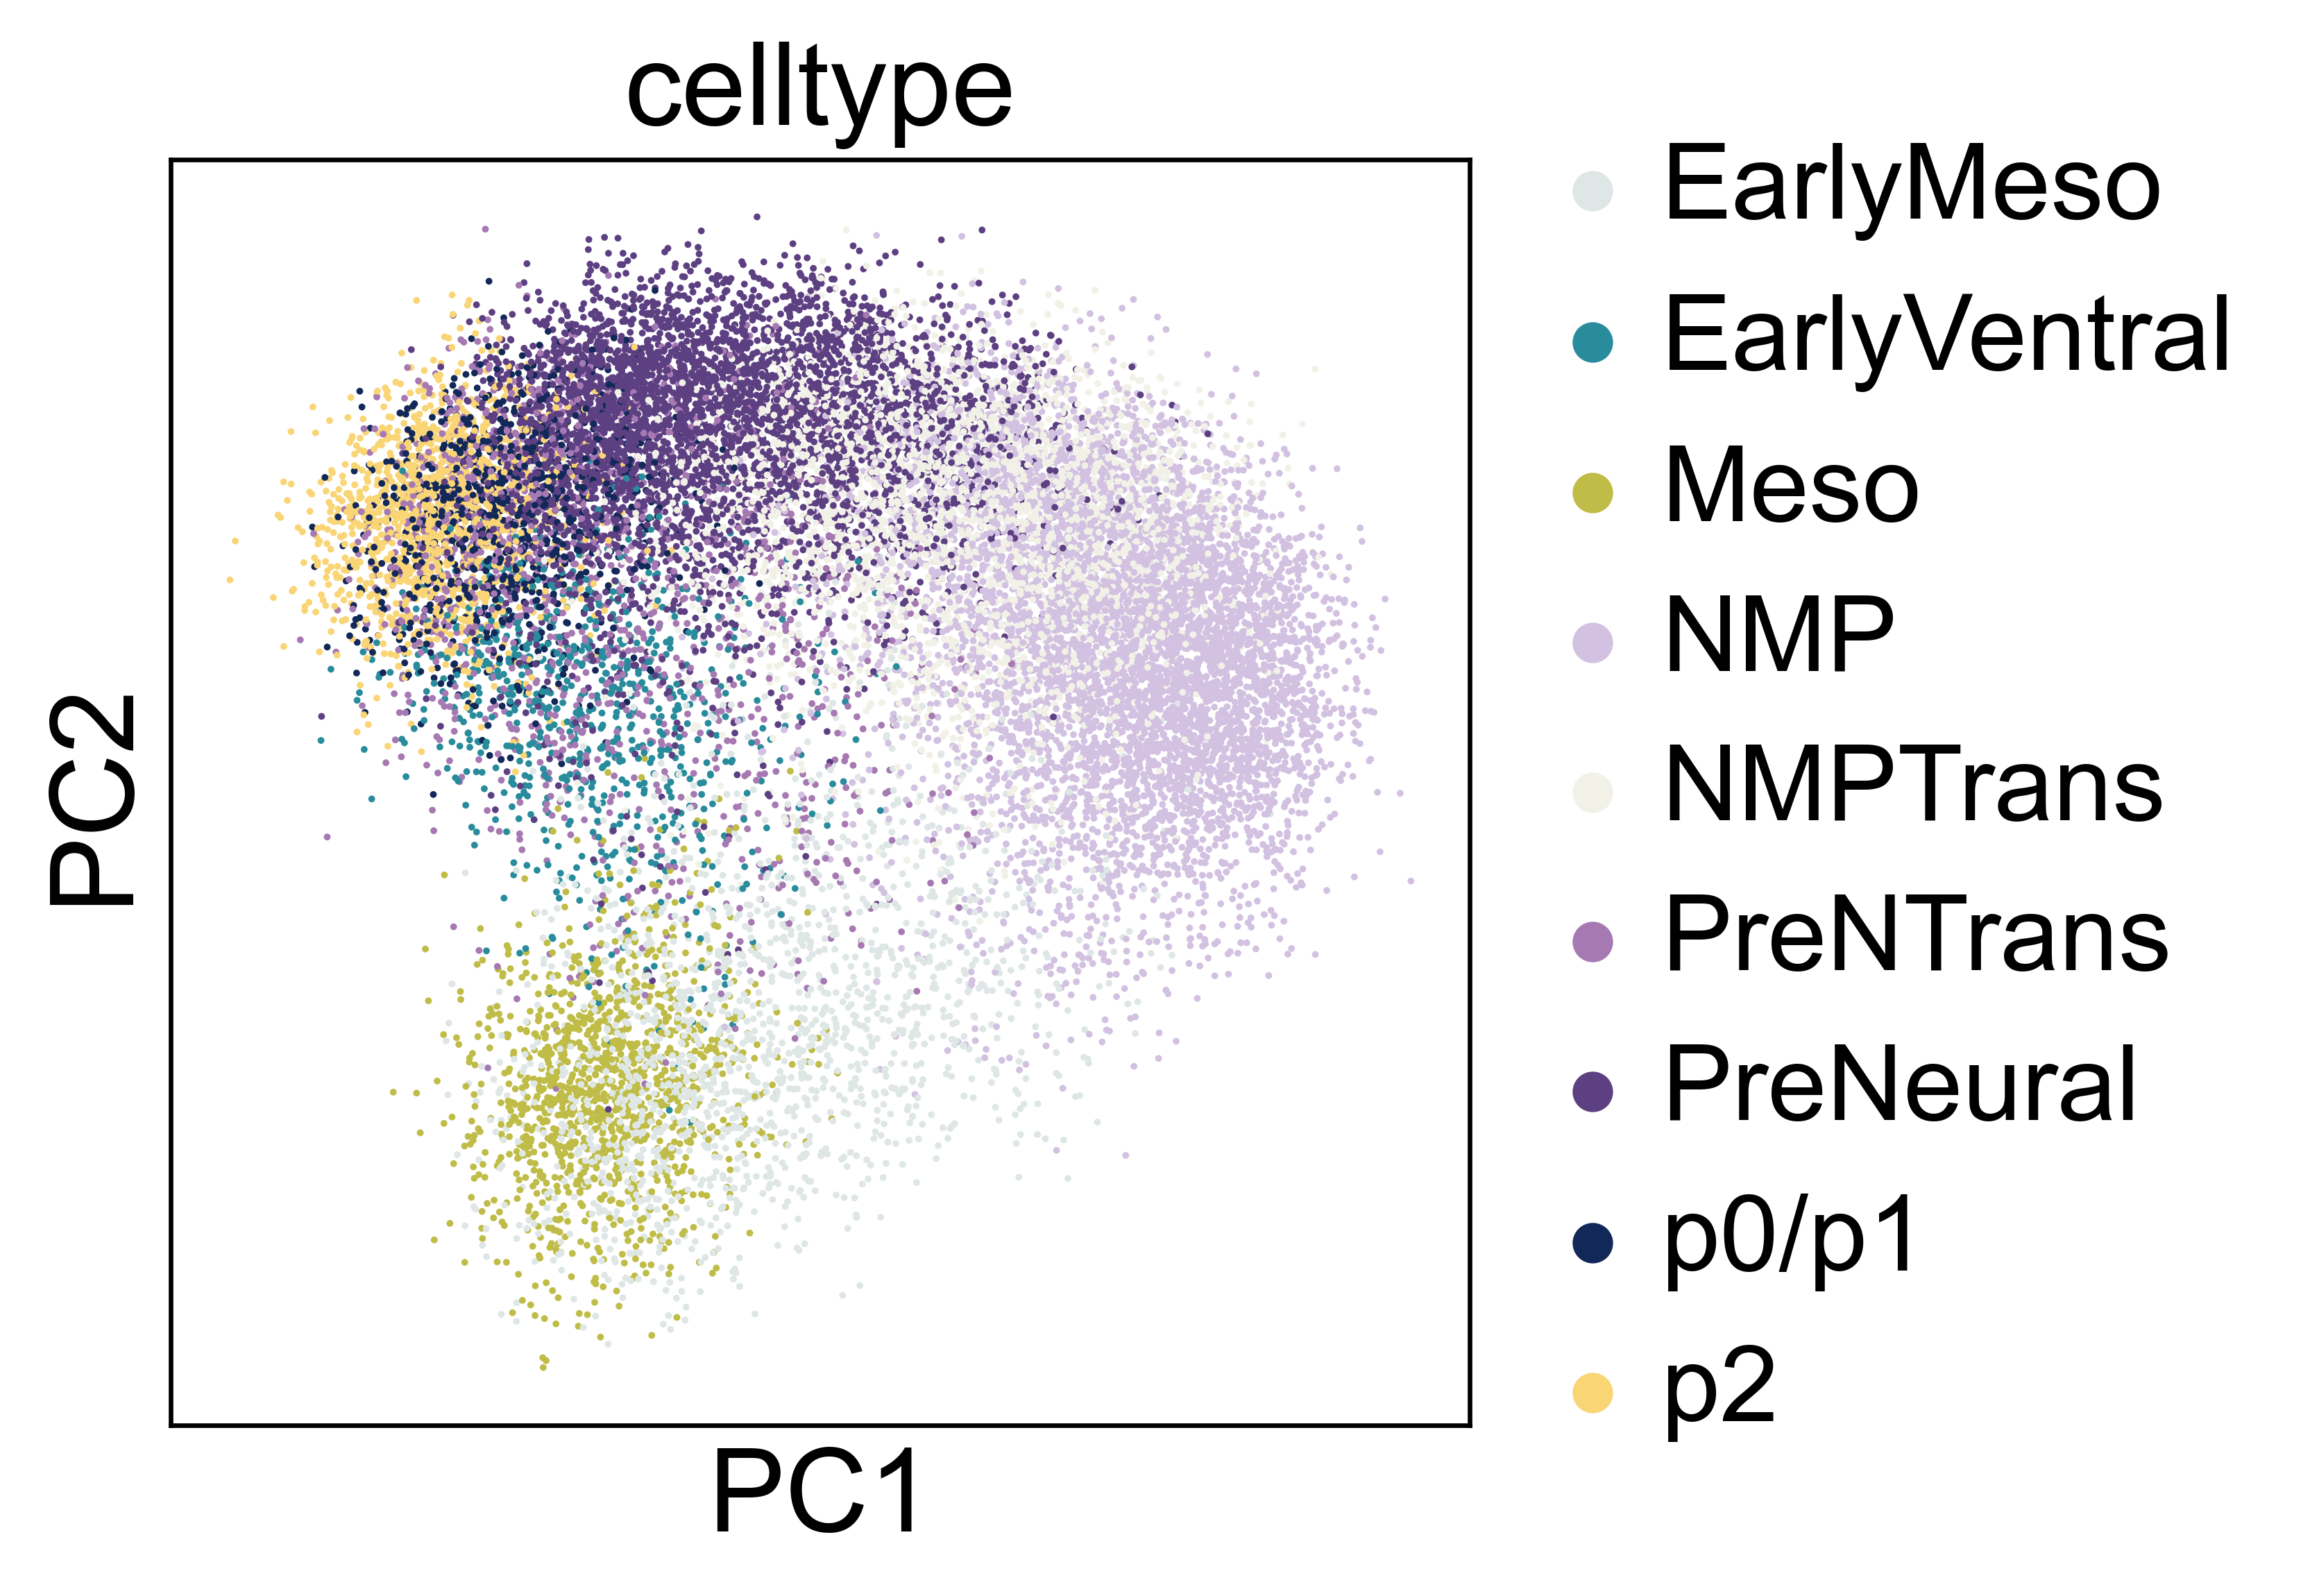

In [30]:
# PCA coloured by annotated cell type (Jun = stressed cells, excluded from plot).
colorpalette={'NMP':'#D2C1E1','Meso':'#BFBC47','NMPTrans':'#f1f1e8','p2':'#F9D575','p0/p1':'#122859','PreNeural':'#5D4082','PreNTrans':'#A679B2','EarlyVentral':'#288c9c','EarlyMeso':'#DEE7E6'}
sc.set_figure_params(scanpy=True, fontsize=20,dpi=300)
sc.pl.pca(neural_states[neural_states.obs['celltype']!='Jun'], color=['celltype'],palette=colorpalette)

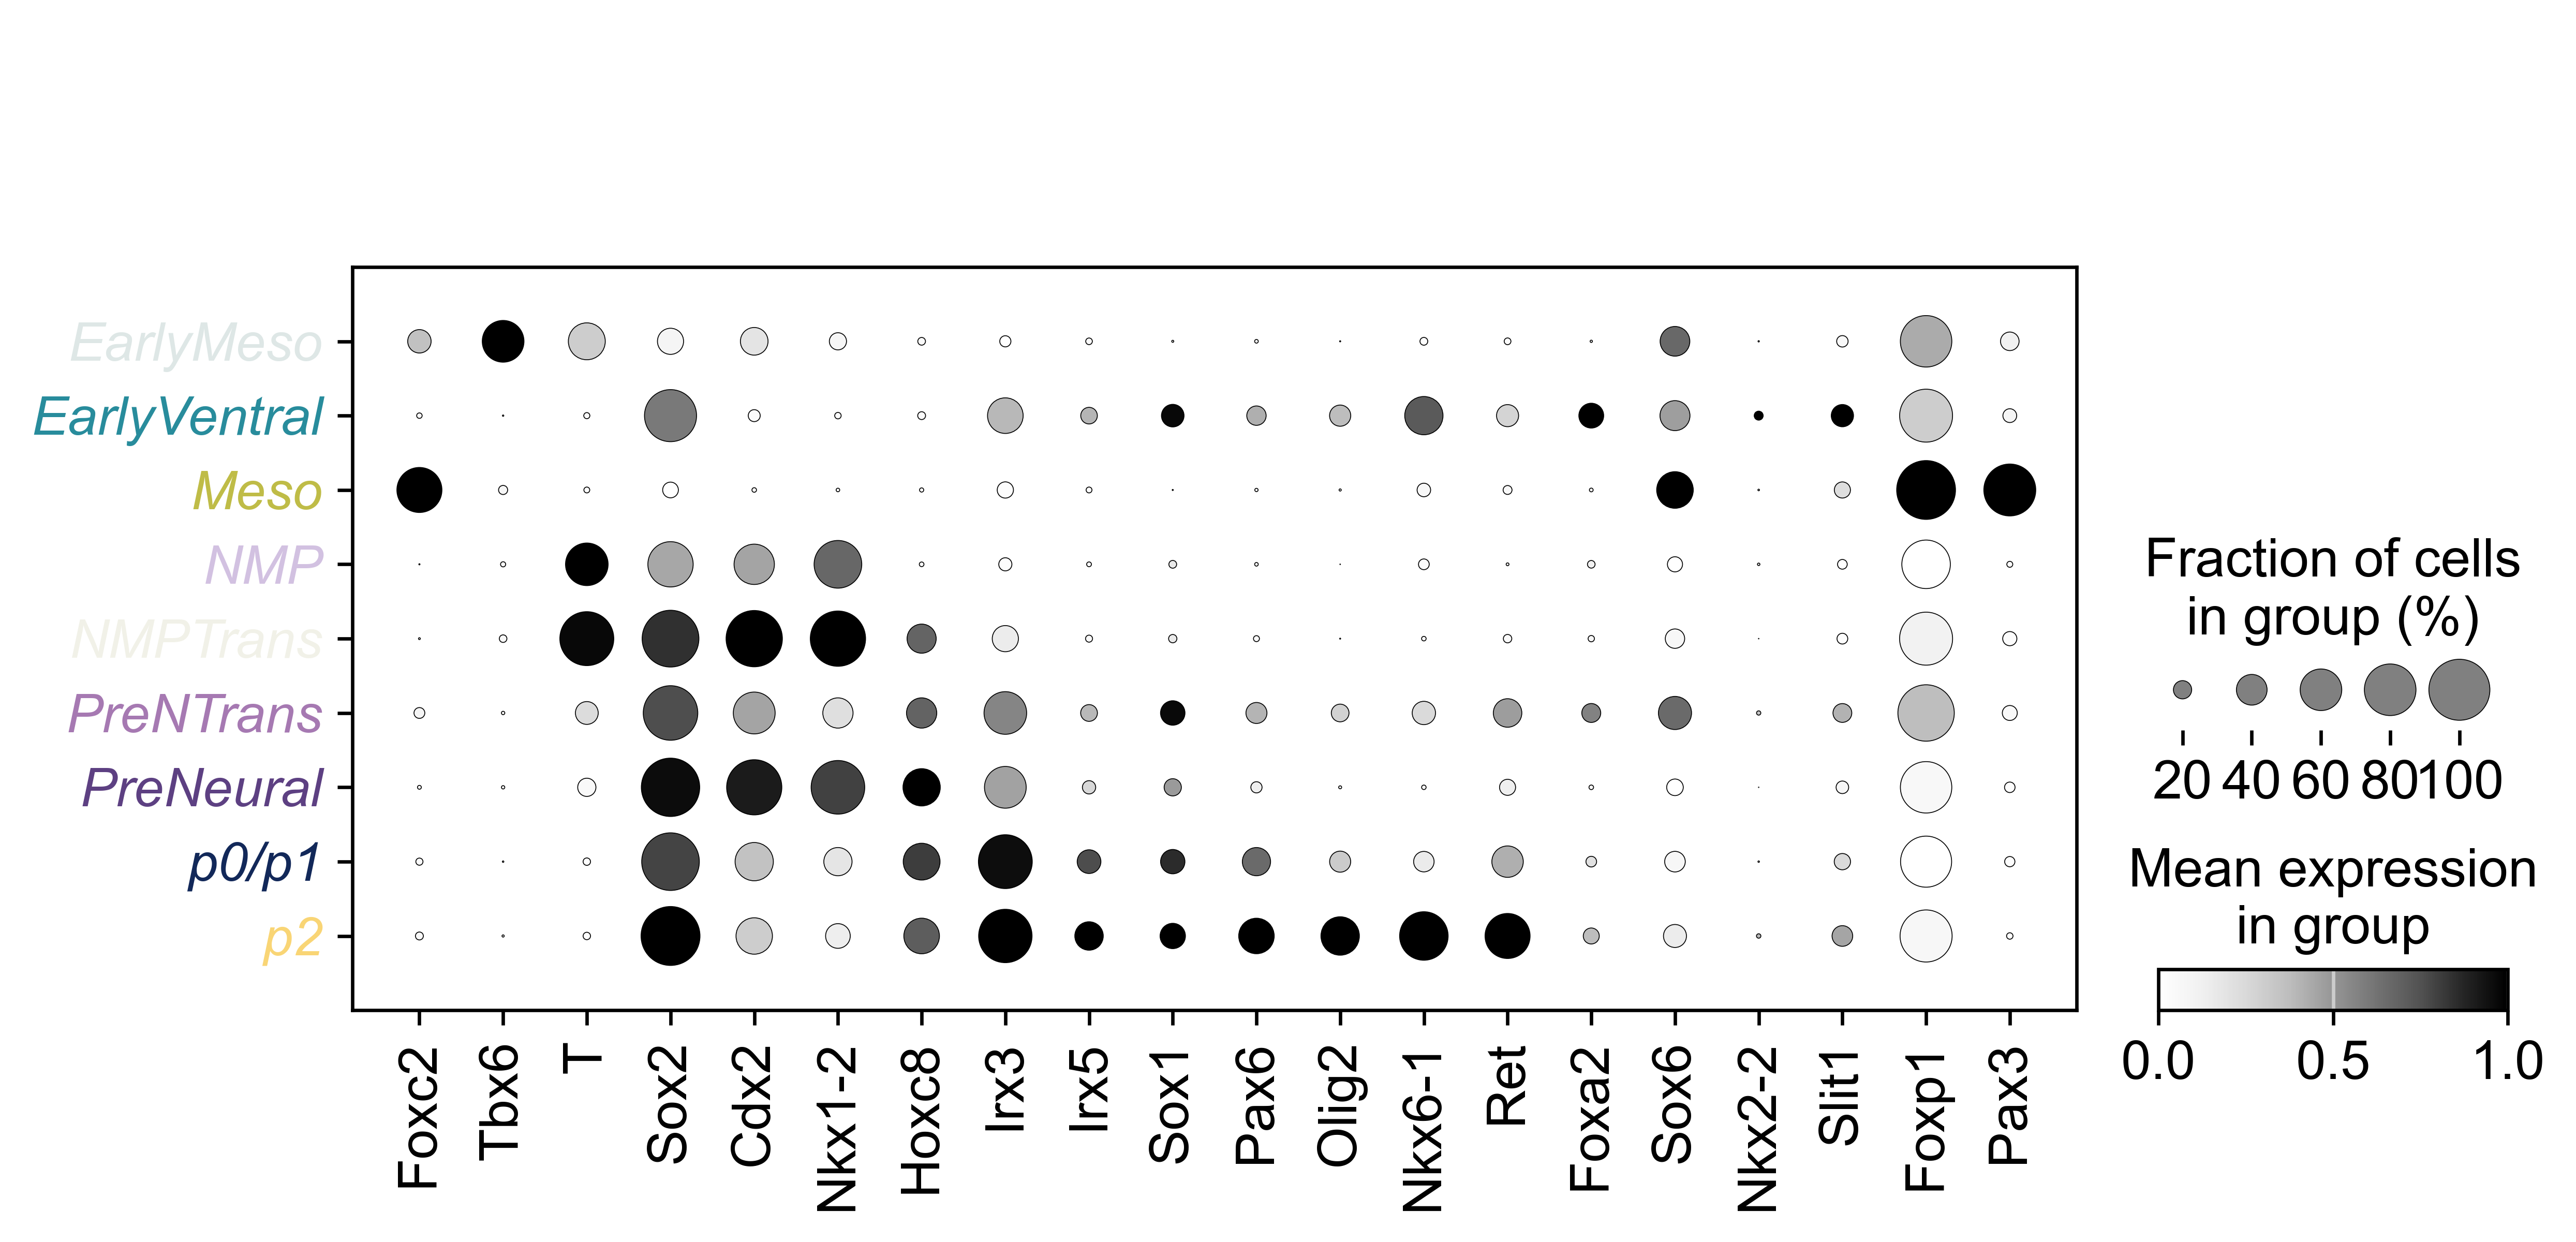

In [32]:
# Dot plot of canonical marker genes per cell type, with gene labels

some_genes=['Foxc2','Tbx6','T','Sox2','Cdx2','Nkx1-2','Hoxc8','Irx3','Irx5','Sox1','Pax6','Olig2','Nkx6-1','Ret','Foxa2','Sox6','Nkx2-2','Slit1','Foxp1','Pax3']

# remove Jun cluster (stressed cells)
ACs=adata_counts[adata_counts.obs['celltype']!='Jun']


sc.set_figure_params(scanpy=True, fontsize=15,dpi=300)
dp=sc.pl.dotplot(ACs,some_genes, groupby='celltype', cmap='Greys',standard_scale='var',swap_axes=False, return_fig=True)
ax=dp.get_axes()["mainplot_ax"]
for l in ax.get_yticklabels():
        l.set_style("italic")
        g=l.get_text()
        l.set_color(colorpalette[g])